# 03 . Monte Carlo validation (Parts I c, I e)

$$Z(0,T) = E^{Q}\left[\exp\left(-\int_0^T r(s)\,ds\right)\right],\qquad T = 5,\ r(0) = 4\%.$$

Paths use the exact transition $r_{k+1} = \alpha r_k + \beta + s Z_k$ (no discretisation error at
grid points), 1260 steps (one per trading day), the integral by the trapezoidal rule, and
antithetic variates.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:.6f}".format

In [2]:
import time
from calibration import fetch_fed_rates, calibrate_vasicek, expected_rate, rate_std
from vasicek import zcb_price, zcb_option_price
from monte_carlo import (simulate_paths, mc_zcb_price, mc_zcb_call,
                         variance_reduction_factor)

fit = calibrate_vasicek(fetch_fed_rates("DFF", start="2000-01-01"))
a, b, sigma = fit["a"], fit["b"], fit["sigma"]
r0, T = 0.04, 5.0
print(f"a = {a:.4f}, b = {b:.4%}, sigma = {sigma:.4%}, r(0) = {r0:.2%}")

a = 0.1900, b = 2.0320%, sigma = 1.2397%, r(0) = 4.00%


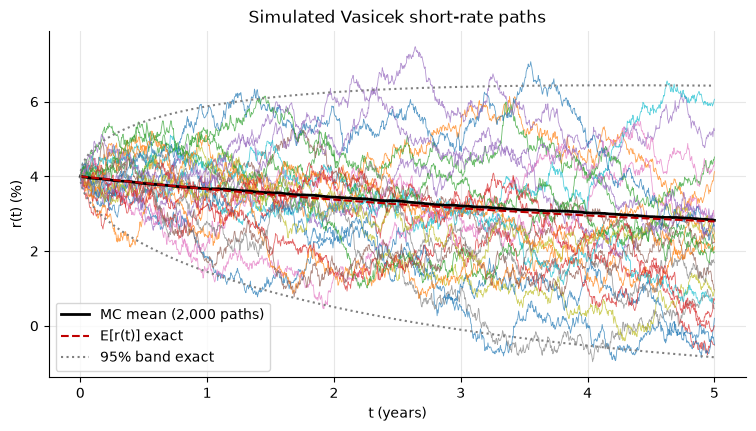

share of paths with r(5) < 0: 7.20%


In [3]:
t, paths = simulate_paths(r0, T, a, b, sigma, n_paths=2000, n_steps=1260, seed=1)
fig, ax = plt.subplots()
ax.plot(t, paths[:25].T * 100, lw=0.6, alpha=0.7)
ax.plot(t, paths.mean(0) * 100, color="black", lw=2, label="MC mean (2,000 paths)")
ax.plot(t, expected_rate(r0, t, a, b) * 100, color="#c00000", ls="--", label="E[r(t)] exact")
ax.plot(t, (expected_rate(r0, t, a, b) + 1.96 * rate_std(t, a, sigma)) * 100, color="grey", ls=":")
ax.plot(t, (expected_rate(r0, t, a, b) - 1.96 * rate_std(t, a, sigma)) * 100, color="grey", ls=":",
        label="95% band exact")
ax.set_xlabel("t (years)"); ax.set_ylabel("r(t) (%)"); ax.set_title("Simulated Vasicek short-rate paths")
ax.legend(); plt.show()
print(f"share of paths with r(5) < 0: {np.mean(paths[:, -1] < 0):.2%}")

## Part I(c): 5-year ZCB by Monte Carlo

In [4]:
tic = time.perf_counter()
mc = mc_zcb_price(r0, T, a, b, sigma, n_paths=50_000, n_steps=1260, seed=42)   # 100,000 paths
elapsed = time.perf_counter() - tic
exact = zcb_price(r0, 0, T, a, b, sigma)

pd.Series({"analytical Z(0,5)": f"{exact:.6f}",
           "Monte Carlo Z(0,5)": f"{mc['price']:.6f}",
           "standard error": f"{mc['std_err']:.2e}",
           "95% CI": f"[{mc['ci_lower']:.6f}, {mc['ci_upper']:.6f}]",
           "error vs analytical": f"{mc['price'] - exact:+.2e}",
           "paths (antithetic pairs x 2)": f"{mc['n_paths']:,}",
           "run time": f"{elapsed:.1f} s"}).to_frame("value")

,value
"analytical Z(0,5)",0.849201
"Monte Carlo Z(0,5)",0.849210
standard error,8.99e-06
95% CI,"[0.849193, 0.849228]"
error vs analytical,+9.49e-06
paths (antithetic pairs x 2),"100,000"
run time,1.9 s


### Convergence: plain MC vs antithetic variates (equal total paths)

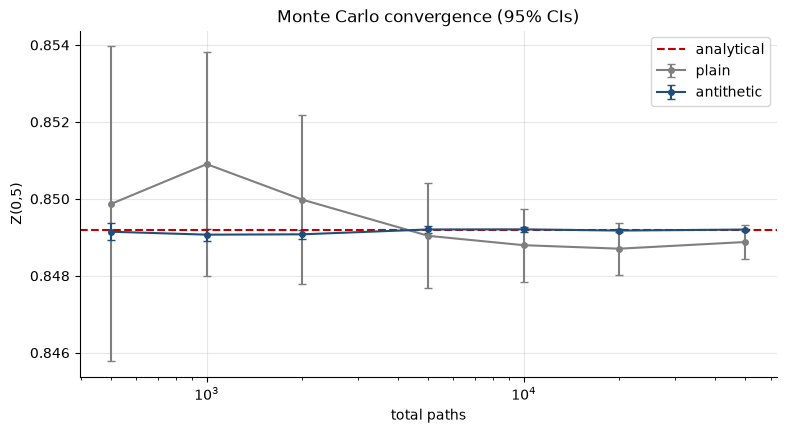

,plain,plain s.e.,antithetic,antithetic s.e.
paths,,,,
500,0.849872,2.09e-03,0.849146,1.12e-04
1000,0.850903,1.48e-03,0.849069,7.85e-05
2000,0.849980,1.12e-03,0.849078,5.72e-05
5000,0.849038,6.95e-04,0.849204,4.07e-05
10000,0.848796,4.86e-04,0.849207,2.87e-05
20000,0.848705,3.44e-04,0.849176,1.93e-05
50000,0.848878,2.20e-04,0.849202,1.27e-05


In [5]:
ns = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
rows = []
for n in ns:
    p = mc_zcb_price(r0, T, a, b, sigma, n_paths=n, n_steps=252, seed=11, antithetic=False)
    q = mc_zcb_price(r0, T, a, b, sigma, n_paths=n // 2, n_steps=252, seed=11, antithetic=True)
    rows.append({"paths": n, "plain": p["price"], "plain s.e.": p["std_err"],
                 "antithetic": q["price"], "antithetic s.e.": q["std_err"]})
conv = pd.DataFrame(rows).set_index("paths")

fig, ax = plt.subplots()
for col, c in [("plain", "#7f7f7f"), ("antithetic", "#1f4e79")]:
    ax.errorbar(conv.index, conv[col], yerr=1.96 * conv[f"{col} s.e."], marker="o", ms=4,
                capsize=3, label=col, color=c)
ax.axhline(exact, color="#c00000", ls="--", label="analytical")
ax.set_xscale("log"); ax.set_xlabel("total paths"); ax.set_ylabel("Z(0,5)")
ax.set_title("Monte Carlo convergence (95% CIs)"); ax.legend(); plt.show()
conv.style.format({"plain": "{:.6f}", "antithetic": "{:.6f}",
                   "plain s.e.": "{:.2e}", "antithetic s.e.": "{:.2e}"})

In [6]:
vr = variance_reduction_factor(r0, T, a, b, sigma, n_paths=20_000, n_steps=252)
print(f"Variance reduction factor (plain / antithetic, same total paths): {vr['factor']:.0f}x")

Variance reduction factor (plain / antithetic, same total paths): 291x


### Variance reduction techniques

* **Antithetic variates** — pair each path built from shocks $Z$ with its mirror built from $-Z$.
* **Control variates** — correct the estimate with a related quantity whose exact value is known.
* **Importance sampling** — sample more often where the payoff matters, reweight by the likelihood ratio.
* **Stratified sampling / Latin hypercube** — force the random inputs to cover their range evenly.
* **Moment matching** — rescale the normals to sample mean 0 and variance 1 exactly.
* **Quasi-Monte Carlo** — low-discrepancy sequences (Sobol, Halton) instead of pseudo-random numbers.
* **Conditional Monte Carlo** — compute part of the expectation analytically, simulate the rest.

**Antithetic variates.** Since $-Z$ has the same distribution as $Z$, the pair average

$$\hat P_{AV} = \frac{1}{M/2}\sum_{i=1}^{M/2}\frac{D(Z^{(i)}) + D(-Z^{(i)})}{2}$$

is unbiased, and for one pair
$\mathrm{Var}\left(\tfrac{D(Z)+D(-Z)}{2}\right) = \tfrac12\left[\mathrm{Var}(D) + \mathrm{Cov}(D(Z),D(-Z))\right]$.
The discount factor falls monotonically as the shocks push rates up, so the covariance is negative.
For small $\sigma$ the discount factor is almost linear in the shocks, and the pairing cancels that
linear part nearly completely — hence the large factor above, at no extra cost in random numbers.

## Part I(e): European call on a 5-year ZCB

Face \$1,000, option expiry $t = 4$ years, strike $K = \$900$. At expiry the bond has one year left:

$$Z(4,5) = 1000\,A(4,5)\,e^{-B(4,5)\,r(4)},\qquad \text{payoff} = \max(Z(4,5) - 900, 0).$$

We simulate $r(4)$ along 100,000 paths and compare three ways of discounting the payoff:

* **pathwise** = each payoff times $e^{-\int_0^4 r\,ds}$ on its own path (the exact risk-neutral price);
* **zcb** = average payoff times $Z(0,4)$, as suggested in the brief (ignores the dependence between
  the discount factor and the payoff);
* **none** = undiscounted average payoff.

The closed-form Vasicek bond option price (Jamshidian) is the benchmark.

In [7]:
opt = dict(T_opt=4.0, T_bond=5.0, face_value=1000.0, K=900.0, n_paths=50_000, n_steps=1008, seed=42)
res = {d: mc_zcb_call(r0, a, b, sigma, **opt, discounting=d) for d in ("pathwise", "zcb", "none")}
closed = zcb_option_price(r0, 4.0, 5.0, 900.0, a, b, sigma, face_value=1000.0)

table = pd.DataFrame({d: {"price": v["price"], "std err": v["std_err"]} for d, v in res.items()}).T
table.loc["closed form"] = [closed, 0.0]
display(table.style.format("{:.4f}"))
z = res["zcb"]
print(f"average payoff at t = 4    : ${z['mean_payoff']:.4f}")
print(f"Z(0,4)                     : {z['P0T']:.6f}")
print(f"C(0) = Z(0,4) x avg payoff : ${z['P0T'] * z['mean_payoff']:.4f}")
print(f"P(option in the money)     : {z['prob_itm']:.2%}")
print(f"forward value 1000 Z(0,5) - 900 Z(0,4) = "
      f"${1000 * zcb_price(r0, 0, 5, a, b, sigma) - 900 * zcb_price(r0, 0, 4, a, b, sigma):.4f}")

,price,std err
pathwise,63.2217,0.0044
zcb,62.7513,0.0007
none,71.8542,0.0008
closed form,63.2172,0.0000


average payoff at t = 4    : $71.8542
Z(0,4)                     : 0.873315
C(0) = Z(0,4) x avg payoff : $62.7513
P(option in the money)     : 100.00%
forward value 1000 Z(0,5) - 900 Z(0,4) = $63.2172


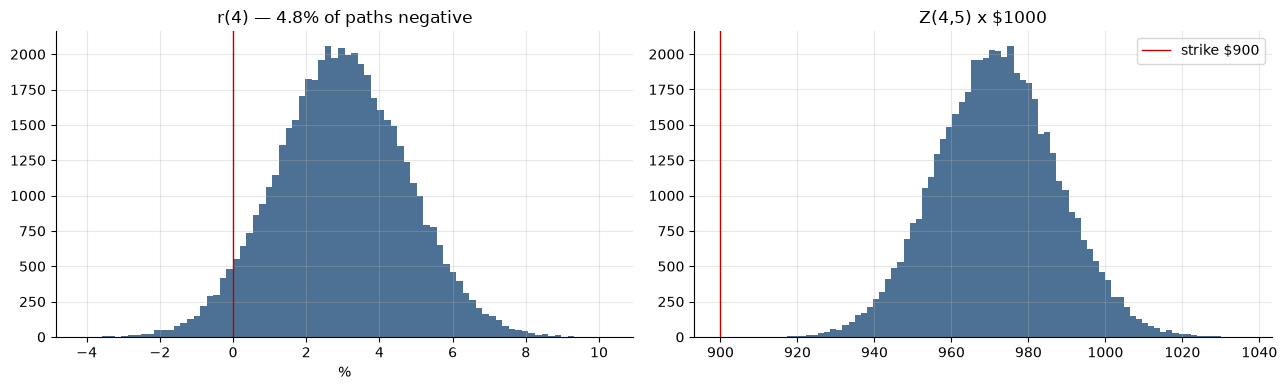

In [7]:
from monte_carlo import simulate_rate_and_integral
rng = np.random.default_rng(5)
(r4, _), _ = simulate_rate_and_integral(r0, 4.0, a, b, sigma, 50_000, 1008, rng)
bond4 = zcb_price(r4, 4.0, 5.0, a, b, sigma, 1000.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(r4 * 100, bins=80, color="#1f4e79", alpha=0.8)
axes[0].axvline(0, color="#c00000", lw=1)
axes[0].set_title(f"r(4) — {np.mean(r4 < 0):.1%} of paths negative"); axes[0].set_xlabel("%")
axes[1].hist(bond4, bins=80, color="#1f4e79", alpha=0.8)
axes[1].axvline(900, color="#c00000", lw=1, label="strike $900")
axes[1].set_title("Z(4,5) x $1000"); axes[1].legend()
plt.tight_layout(); plt.show()

**Comments.** The pathwise MC price agrees with the closed form within its standard error.
With $K = 900$ and a one-year bond the option is almost always in the money, so its value is close to
the forward value $1000\,Z(0,5) - 900\,Z(0,4)$. The "zcb" shortcut from the brief differs slightly
because it ignores the covariance between the discount factor and the bond price at $t=4$.
Negative simulated rates (left histogram) push $Z(4,5)$ above face value — the known Vasicek limitation.